# Meta: Improvment

In [12]:
# Imports
import os, json, sys
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import numpy as np
import seaborn as sns

In [13]:
prompt = "prompt8"
prompt2 = "prompt9"
gt_id = "gtb.45af4a46-d258-4251-b734-d407602299bd"

In [14]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
prompt_dir = os.path.join(evaluations_dir, prompt)
prompt_dir2 = os.path.join(evaluations_dir, prompt2)
db_path = os.path.join(data_dir, "DB.db")
gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")

In [15]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [16]:
# Evaluations Unique IDs
unique_ids_medium2 = [
    "g2m-7-9.4d9feeee-c979-4c5a-8779-21889b49d63b", #gemma2:9b
    "l3m-1-9.02ec842c-c539-4fb5-b4fe-29fa29c878ee", #llama3:8b
    "l31m-3-9.85830d48-11a6-4fc2-9fa6-b45fc9a80348", #llama3.1:8b
    "mm-9-9.d7180795-ae97-4e5e-87de-e3ce3b689c00", #mistral-nemo:12b
]

unique_ids_medium = [
    "g2m-7-8.2bfda31a-5a91-4127-86b0-764d900776d1", #gemma2:9b
    "l3m-1-8.c8c48325-828d-4d41-8fc9-4f0d3880b56a", #llama3:8b
    "l31m-3-8.a2192fb0-40a9-426a-9780-3ddcb70eddac", #llama3.1:8b
    "mm-9-8.a7c9bf93-a276-4d45-a15f-e02c39bd7a07", #mistral-nemo:12b
]

In [17]:
# gt_res
with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]

In [18]:
def load_evaluations(unique_ids, prompt_dir):
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

In [19]:
res1 = load_evaluations(unique_ids_medium, prompt_dir)
res2 = load_evaluations(unique_ids_medium2, prompt_dir2)

In [20]:
def similarity_rating_graph(model_res1, model_res2, metric):
    "show a bar graph of the similarity ratings between two datasets"
    ratings1 = model_res1["metrics"]["semantic_metrics"][metric]
    ratings2 = model_res2["metrics"]["semantic_metrics"][metric]

    # Count the frequency of each rating (1 to 5)
    freq1 = [ratings1.count(i) for i in range(1, 6)]
    freq2 = [ratings2.count(i) for i in range(1, 6)]

    fig, ax = plt.subplots(figsize=(10, 5))

    indices = np.arange(1, 6)
    bar_width = 0.35

    # Plot the frequencies side by side
    bars1 = ax.bar(indices - bar_width/2, freq1, bar_width, color='skyblue', label=f'{model_res1["model"]["name"]}:{model_res1["model"]["size"]}-{model_res1["prompt"]["id"]}')
    bars2 = ax.bar(indices + bar_width/2, freq2, bar_width, color='lightgreen', label=f'{model_res2["model"]["name"]}:{model_res2["model"]["size"]}-{model_res2["prompt"]["id"]}')

    # Set the labels and title
    ax.set_title(f"Similarity Ratings for {metric}")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Frequency")
    ax.set_xticks(indices)
    ax.set_xticklabels(indices)

    ax.grid(True, color="gray", linestyle="--", linewidth=0.5, axis="y")
    ax.legend()

    fig.tight_layout()
    return fig, ax

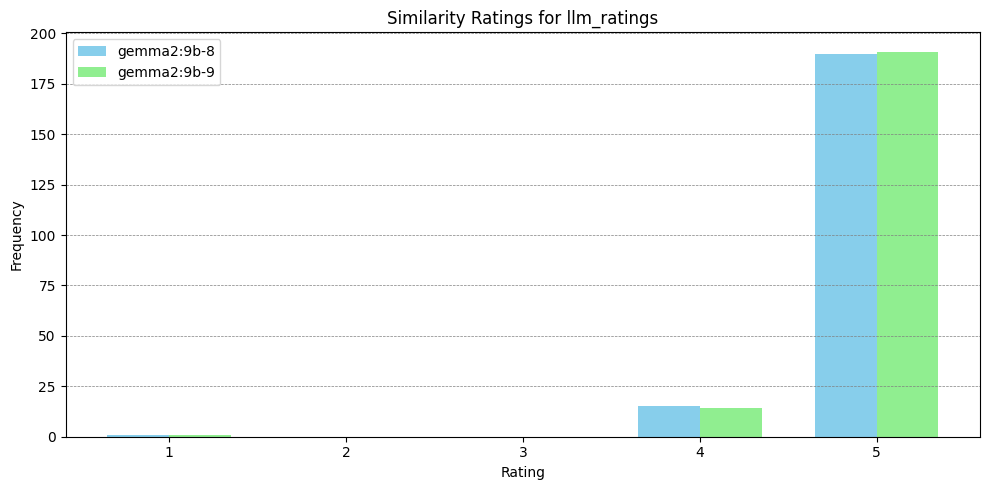

In [21]:
fig, ax = similarity_rating_graph(res1[0], res2[0], "llm_ratings")

In [22]:
mn = 2
ratings1 = res1[mn]["metrics"]["semantic_metrics"]["llm_ratings"]
ratings2 = res2[mn]["metrics"]["semantic_metrics"]["llm_ratings"]

scores1 = res1[mn]["metrics"]["semantic_metrics"]["llm_scores"]
scores2 = res2[mn]["metrics"]["semantic_metrics"]["llm_scores"]

indexed_ratings1 = [(index, rating, scores1[index]) for index, rating in enumerate(ratings1)]
indexed_ratings2 = [(index, rating, scores2[index]) for index, rating in enumerate(ratings2)]

print(f"{res1[mn]['model']['name']}:{res1[mn]['model']['size']}-{res1[mn]['prompt']['id']}")
for index, rating, score in indexed_ratings1:
    if rating < 5:
        print(f"Index: {index + 1}, Rating: {rating}, Score: {score}")

print(f"{res2[mn]['model']['name']}:{res2[mn]['model']['size']}-{res2[mn]['prompt']['id']}")
for index, rating, score in indexed_ratings2:
    if rating < 5:
        print(f"Index: {index + 1}, Rating: {rating}, Score: {score}")

llama3.1:8b-8
Index: 62, Rating: 4, Score: 0.95
Index: 68, Rating: 4, Score: 0.95
Index: 87, Rating: 2, Score: 0.27
Index: 116, Rating: 4, Score: 0.98
Index: 126, Rating: 4, Score: 0.98
Index: 182, Rating: 4, Score: 0.98
Index: 201, Rating: 4, Score: 0.6
llama3.1:8b-9
Index: 23, Rating: 4, Score: 0.98
Index: 65, Rating: 4, Score: 0.95
Index: 83, Rating: 4, Score: 0.95
Index: 87, Rating: 2, Score: 0.25
Index: 122, Rating: 4, Score: 0.98
Index: 140, Rating: 3, Score: 0.8
Index: 182, Rating: 4, Score: 0.95
Index: 201, Rating: 4, Score: 0.7


# 201
## GT
lich: neu Leistenhernie links\nFragestellung\nVK, aktuell deutliche AZ Verschlechterung. \nV.a. Progress.\nKontrastmittel\n80 ml Ultravist 370mgJod/ml (500 ml)\nMethodik\nSpiral-CT-Untersuchung von Hals, Thorax und Abdomen mit gewichtsadaptierter intravenöser Applikation eines nicht-ionischen Kontrastmittels (Ultravist 370). Erfassung von Hals, Thorax und Abdomen in venöser, des Oberbauches zusätzlich in arterieller Kontrastmittelphase. 5 / 4 / 1 mm Rekonstruktionen in Weichteil- und Lungenfenstertechnik. Computergestützte Analyse und Anfertigung multiplanarer Reformationen. CT-Angiographie-Rekonstruktionen in coronarer und sagittaler Orientierung.\nBefund\nMehrere Voruntersuchungen zum Befundvergleich vorliegend, des Halses zuletzt vom 15.12.2023, des Thorax und des Abdomens zuletzt vom 13.05.2024.\n\nHals:\nAufhärtungsartefakte durch röntgendichten Zahnersatz. Kein Nachweis einer zervikalen Raumforderung oder pathologisch vergrößerter Lymphknoten. Unauffällige Darstellung der Schilddrüse.\n\nThorax:Vorbekannte vereinzelte bipulmonale Lungenmetastasen mit insgesamt fluktuierendem Verlauf; einzelne intrapulmonale Rundherde zeigen sich zur Voruntersuchung größenregredient, andere Rundherde beidseits sind neu zur oben genannten Voruntersuchung abgrenzbar. Bekannte dystelektatische Veränderungen, betont links ventrobasal und im rechten Unterlappen nach operativer Metastasenresektion. Keine pneumonischen Infiltrate. Keine Pleuraergüsse.\nDer vorbekannte, vormals größenprogrediente Thrombus in der proximalen Vena cava inferior zeigt sich zur Voruntersuchung deutlich größenprogredient und reicht jetzt bis in den rechten Vorhof und rechten Ventrikel unter weitestgehender Ausfüllung des Lumens des rechten Vorhofs, der maximale axiale Durchmesser beträgt aktuell ca. 6,3 x 4,9 cm (Voruntersuchung: 4,0 x 2,2 cm) DD Tumorwachstum mit Appositionsthrombus. Zudem neu abgrenzbare Lungenarterienembolie in der rechten Unterlappenarterie.\nNormal großes Herz. Kein Perikarderguss. Vorwiegend länglich-ovalär konfigurierte, zum Teil etwas vergrößerte mediastinale Lymphknoten, idem.\n\nAbdomen:\nDas vorbekannte, zentral in der Leber lokalisierte CCC kommt im Vergleich zur Voruntersuchung größenregredient zur Darstellung, reichert aktuell weniger Kontrastmittel an und weist zentral deutlicher ausgeprägte nekrotische Anteile auf, aktueller axialer Durchmesser ca. 9,7 x 8,7 cm (Voruntersuchung: 10,4 x 10,1 cm). Der bekannte Satellitenherd angrenzend an das Ligamentum falciforme in Lebersegment IVb stellt sich ebenfalls größenregredient dar und misst aktuell ca. 2,5 x 2,3 cm (Voruntersuchung: 4,9 x 3,5 cm). Der ebenfalls vorbekannte Satellitenherd in Segment IVa stellt sich ebenfalls größenregredient dar, aktueller axialer Durchmesser ca. 1,5 x 1,5 cm (Voruntersuchung: 2,2 x 2,1 cm). Größenkonstante Darstellung der vorbekannten Biliome, exemplarisch das größte in Lebersegment VIII, axial ca. 1,8 x 1,6 cm messend. Kein Nachweis entzündlicher Umgebungsreaktionen.\nUnveränderte Lage der bekannten einliegenden Gallengangsstents links und rechts hepatisch. Hierunter weiterhin unverändert insbesondere linkshepatisch betonte Cholestase, geringer auch bekannte rechts hepatische Cholestase. Bekannte Thrombose des rechten Pfortaderhauptstammes mit nachfolgend noch flauer Kontrastierung des anteromedialen und posterolateralen Pfortaderastes. Im Übrigen regelrechte Kontrastierung der Lebervenen und der Pfortader.\nAusgeprägte Splenomegalie, aktueller ventrodorsaler Durchmesser ca. 18,1 cm. Konstante Zeichen der portalen Hypertension bei Splenomegalie und varikös veränderter Milzvene und splenorenalen Shunts. Größenprogredienz der vorbekannten Nebennierenraumforderung rechts, aktueller axialer Durchmesser ca. 2,7 x 1,8 cm (Voruntersuchung: 2,3 x 1,6 cm), aktuell hypodenser im Vergleich zur Voruntersuchung und in Zusammenschau mit der MRT aus 08/2023 in erster Linie einem Adenom entsprechend. Sigmadivertikulose. Deutlich flüssigkeitsgefüllte Darstellung der Dünndarmschlingen ohne Nachweis von Luft-Flüssigkeitsspiegeln. Im Übrigen unauffällige Darstellung der parenchymatösen Bauchorgane sowie der Darmschlingen. Geringe Mengen freier Flüssigkeit im kleinen Becken. Keine abdominelle Lymphadenopathie. Truncus coeliaco-mesentericus, hieraus entspringt die A. hepatica sinistra, auf die AMS transponierte A. hepatica dextra. Direktabgang der A. gastrica sinistra aus der Aorta. \n\nSkelett:\nSpondylolisthesis vera LWK 5/SWK 1, idem. Keine malignomsuspekten ossären Läsionen. Degenerative Wirbelsäulenveränderungen. Einzelne mehrsklerosierte Läsionen mehrerer rechtsseitiger Rippen (exemplarisch 7. Rippe rechts lateral), nicht suspekt, idem.

## llama3.1:8b-8
Ich bin kein Arzt und kann keine spezifischen medizinische Diagnose oder Empfehlungen stellen. Ich kann jedoch versuchen, einige Aspects der vorliegenden Untersuchungsergebnisse zu analysieren.\n\nEs scheint, dass die Patientin/der Patient folgende Erkrankungen und Veränderungen aufweist:\n\n1. **Thrombus in der Vena cava inferior**: Es ist erwähnt, dass ein Thrombus in der proximalen Vena cava inferior vorhanden ist, der deutlich größer und progredient ist. Dies könnte zu thrombo-embolischen Ereignissen führen.\n2. **Lungenarterienembolie**: Eine Lungenarterienembolie in der rechten Unterlappenarterie wurde festgestellt.\n3. **Cholangiozysten-Karzinom (CCC)**: Das CCC ist größenregredient und zeigt nekrotische Anteile. Dies könnte auf eine fortschreitende Erkrankung hindeuten.\n4. **Satellitenherde**: Es gibt zwei Satellitenherde in der Leber, die ebenfalls größenregressiv sind.\n5. **Biliome**: Biliome werden erwähnt, aber es ist nicht klar, ob sie sich verändert haben.\n6. **Portalhypertonie**: Die Patientin/der Patient zeigt Zeichen einer portalen Hypertonie, was auf eine Erhöhung des Drucks in den Pfortaderästen hinweist.\n7. **Splenomegalie**: Es gibt ausgeprägte Splenomegalie, was auf eine vermehrte Größe der Milz hinweist.\n8. **Nebennierenraumforderung**: Eine Nebennierenraumforderung rechts wurde festgestellt, die größenregredient ist und hypodenser im Vergleich zur Voruntersuchung erscheint.\n\nEs ist wichtig zu beachten, dass diese Analyse nur eine allgemeine Einschätzung darstellt und nicht von einem Arzt geprüft werden sollte. Die Patientin/der Patient benötigt eine umfassende medizinische Beurteilung und Beratung durch einen qualifizierten Arzt, um die beste Vorgehensweise zu bestimmen.
## llama3.1:8b-9
Es scheint, dass du ein medizinisches Bericht dokumentiert hast. Ich werde mein Bestes tun, um die wichtigsten Punkte aus diesem Bericht zusammenzufassen.\n\n**Klinische Befunde:**\n\n* Ein großes Thrombus in der proximalen Vena cava inferior wurde gefunden, das sich von der Voruntersuchung deutlich vergrößert hat und bis zum rechten Ventrikel reicht.\n* Eine Lungenarterienembolie in der rechten Unterlappenarterie wurde gefunden.\n\n**Untersuchungsergebnisse:**\n\n* Das CCC (Cholangio-Karzinom) ist größenregredient und zeigt nekrotische Anteile auf.\n* Zwei Satellitenherde in der Leber wurden gefunden, die sich ebenfalls größenregressiv entwickelt haben.\n* Die Biliome sind konstant groß geblieben.\n* Keine entzündlichen Umgebungsreaktionen wurden gefunden.\n\n**Abdominelle Untersuchungsergebnisse:**\n\n* Eine ausgeprägte Splenomegalie wurde festgestellt, mit einem Durchmesser von 18,1 cm.\n* Zeichen der portalen Hypertension bei Splenomegalie und varikös veränderter Milzvene und splenorenalen Shunts wurden gefunden.\n* Die vorbekannte Nebennierenraumforderung rechts ist größenprogredienz entwickelt worden.\n\n**Sonstige Befunde:**\n\n* Eine Spondylolisthesis vera LWK 5/SWK 1 wurde festgestellt.\n* Keine malignomsuspekten ossären Läsionen wurden gefunden.\n* Einzelne mehrsklerosierte Läsionen mehrerer rechtsseitiger Rippen wurden gefunden.\n\nEs ist wichtig zu beachten, dass dieser Bericht medizinische Fachsprache verwendet und von einem Fachmann interpretiert werden sollte. Wenn du weitere Fragen hast oder Hilfe bei der Interpretation benötigst, stehe ich gerne zur Verfügung.

## Reasons
### might be running into Constraints
- "Ich bin kein Arzt und kann keine spezifischen medizinische Diagnose oder Empfehlungen stellen."
- "Es scheint, dass du ein medizinisches Bericht dokumentiert hast"

### I cut the report at the wrong spot, it should be this:
Mehrere Voruntersuchungen zum Befundvergleich vorliegend, des Halses zuletzt vom 15.12.2023, des Thorax und des Abdomens zuletzt vom 13.05.2024.\n\nHals:\nAufhärtungsartefakte durch röntgendichten Zahnersatz. Kein Nachweis einer zervikalen Raumforderung oder pathologisch vergrößerter Lymphknoten. Unauffällige Darstellung der Schilddrüse.\n\nThorax:Vorbekannte vereinzelte bipulmonale Lungenmetastasen mit insgesamt fluktuierendem Verlauf; einzelne intrapulmonale Rundherde zeigen sich zur Voruntersuchung größenregredient, andere Rundherde beidseits sind neu zur oben genannten Voruntersuchung abgrenzbar. Bekannte dystelektatische Veränderungen, betont links ventrobasal und im rechten Unterlappen nach operativer Metastasenresektion. Keine pneumonischen Infiltrate. Keine Pleuraergüsse.\nDer vorbekannte, vormals größenprogrediente Thrombus in der proximalen Vena cava inferior zeigt sich zur Voruntersuchung deutlich größenprogredient und reicht jetzt bis in den rechten Vorhof und rechten Ventrikel unter weitestgehender Ausfüllung des Lumens des rechten Vorhofs, der maximale axiale Durchmesser beträgt aktuell ca. 6,3 x 4,9 cm (Voruntersuchung: 4,0 x 2,2 cm) DD Tumorwachstum mit Appositionsthrombus. Zudem neu abgrenzbare Lungenarterienembolie in der rechten Unterlappenarterie.\nNormal großes Herz. Kein Perikarderguss. Vorwiegend länglich-ovalär konfigurierte, zum Teil etwas vergrößerte mediastinale Lymphknoten, idem.\n\nAbdomen:\nDas vorbekannte, zentral in der Leber lokalisierte CCC kommt im Vergleich zur Voruntersuchung größenregredient zur Darstellung, reichert aktuell weniger Kontrastmittel an und weist zentral deutlicher ausgeprägte nekrotische Anteile auf, aktueller axialer Durchmesser ca. 9,7 x 8,7 cm (Voruntersuchung: 10,4 x 10,1 cm). Der bekannte Satellitenherd angrenzend an das Ligamentum falciforme in Lebersegment IVb stellt sich ebenfalls größenregredient dar und misst aktuell ca. 2,5 x 2,3 cm (Voruntersuchung: 4,9 x 3,5 cm). Der ebenfalls vorbekannte Satellitenherd in Segment IVa stellt sich ebenfalls größenregredient dar, aktueller axialer Durchmesser ca. 1,5 x 1,5 cm (Voruntersuchung: 2,2 x 2,1 cm). Größenkonstante Darstellung der vorbekannten Biliome, exemplarisch das größte in Lebersegment VIII, axial ca. 1,8 x 1,6 cm messend. Kein Nachweis entzündlicher Umgebungsreaktionen.\nUnveränderte Lage der bekannten einliegenden Gallengangsstents links und rechts hepatisch. Hierunter weiterhin unverändert insbesondere linkshepatisch betonte Cholestase, geringer auch bekannte rechts hepatische Cholestase. Bekannte Thrombose des rechten Pfortaderhauptstammes mit nachfolgend noch flauer Kontrastierung des anteromedialen und posterolateralen Pfortaderastes. Im Übrigen regelrechte Kontrastierung der Lebervenen und der Pfortader.\nAusgeprägte Splenomegalie, aktueller ventrodorsaler Durchmesser ca. 18,1 cm. Konstante Zeichen der portalen Hypertension bei Splenomegalie und varikös veränderter Milzvene und splenorenalen Shunts. Größenprogredienz der vorbekannten Nebennierenraumforderung rechts, aktueller axialer Durchmesser ca. 2,7 x 1,8 cm (Voruntersuchung: 2,3 x 1,6 cm), aktuell hypodenser im Vergleich zur Voruntersuchung und in Zusammenschau mit der MRT aus 08/2023 in erster Linie einem Adenom entsprechend. Sigmadivertikulose. Deutlich flüssigkeitsgefüllte Darstellung der Dünndarmschlingen ohne Nachweis von Luft-Flüssigkeitsspiegeln. Im Übrigen unauffällige Darstellung der parenchymatösen Bauchorgane sowie der Darmschlingen. Geringe Mengen freier Flüssigkeit im kleinen Becken. Keine abdominelle Lymphadenopathie. Truncus coeliaco-mesentericus, hieraus entspringt die A. hepatica sinistra, auf die AMS transponierte A. hepatica dextra. Direktabgang der A. gastrica sinistra aus der Aorta. \n\nSkelett:\nSpondylolisthesis vera LWK 5/SWK 1, idem. Keine malignomsuspekten ossären Läsionen. Degenerative Wirbelsäulenveränderungen. Einzelne mehrsklerosierte Läsionen mehrerer rechtsseitiger Rippen (exemplarisch 7. Rippe rechts lateral), nicht suspekt, idem.